# 03_Feature_Engineering

# 1. Carga de datos y preparación

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import sys
from sklearn.model_selection import train_test_split
import matplotlib as plt
import matplotlib.pyplot as plt

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

ROOT_DIR = Path(root_path)

import src.utils.utils as utils

%load_ext autoreload
%autoreload 2

DATA_PATH = ROOT_DIR /"notebooks" / "data" / "processed" / "telco_customers_churn_EDA.parquet"
REPORTS_DIR = ROOT_DIR / "reports" / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el archivo en: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH)


df.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,customer_i_d,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df.dtypes

customer_i_d         string[python]
gender                     category
senior_citizen                int64
partner                    category
dependents                 category
tenure                        int64
phone_service              category
multiple_lines             category
internet_service           category
online_security            category
online_backup              category
device_protection          category
tech_support               category
streaming_t_v              category
streaming_movies           category
contract                   category
paperless_billing          category
payment_method             category
monthly_charges             float64
total_charges               float64
churn                      category
dtype: object

In [20]:
df['senior_citizen'] = df['senior_citizen'].astype('category')

# 2. Feature engineering

Encapsulamos toda la ingeniería de variables en una función para que luego sea reutilizable en el pipeline.

In [21]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Variables binarias a 0/1
    binary_map = {"Yes": 1, "No": 0}
    for col in ["partner", "dependents", "phone_service", "paperless_billing", "churn"]:
        if col in df.columns:
            # Añadimos .astype(int) para que dejen de ser 'category' y sean números
            df[col] = df[col].map(binary_map).astype(int)

    # Feature: personas a cargo / tamaño familiar aproximado
    if "partner" in df.columns and "dependents" in df.columns:
        df["family_support"] = df["partner"].fillna(0) + df["dependents"].fillna(0)

    # Feature: antigüedad en forma binaria
    if "tenure" in df.columns:
        df["is_new_customer"] = (df["tenure"] <= 3).astype(int) # la condición <= Devuelve True o False, y con astype(int) lo transforma a 0/1
        df["is_long_term_customer"] = (df["tenure"] >= 24).astype(int)

    # Feature: gasto medio acumulado por mes de antigüedad
    if "total_charges" in df.columns and "tenure" in df.columns:
        df["avg_charge_per_tenure"] = np.where(
            df["tenure"] > 0,
            df["total_charges"] / df["tenure"],
            np.nan
        )

    # Feature: relación entre cargo mensual y antigüedad
    if "monthly_charges" in df.columns and "tenure" in df.columns:
        df["monthly_to_tenure_ratio"] = np.where(
            df["tenure"] > 0,
            df["monthly_charges"] / (df["tenure"] + 1), # Sumamos 1 para tener en cuenta el primer mes 
            np.nan
        )

    # Feature: número de servicios contratados
    service_cols = [
        "phone_service",
        "multiple_lines",
        "online_security",
        "online_backup",
        "device_protection",
        "tech_support",
        "streaming_tv",
        "streaming_movies",
    ]

    existing_service_cols = [c for c in service_cols if c in df.columns]

    if existing_service_cols:
        # En Telco, la mayoría de servicios son Yes/No/No internet service
        for col in existing_service_cols:
            df[col] = df[col].replace({
                "Yes": 1,
                "No": 0,
                "No internet service": 0,
                "No phone service": 0
            })
        # Creamos una nueva variable tipo "Engagement". Si un cliente tiene PhoneService + InternetService + StreamingTV +... 
        # suma más que uno que solo tiene PhoneService
        df["services_count"] = df[existing_service_cols].sum(axis=1) 

    # Feature: tipo de contrato más estable
    if "contract" in df.columns:
        df["is_month_to_month"] = (df["contract"] == "Month-to-month").astype(int)
        df["is_one_year_contract"] = (df["contract"] == "One year").astype(int)
        df["is_two_year_contract"] = (df["contract"] == "Two year").astype(int)

    # Feature: pago automático
    if "payment_method" in df.columns:
        df["has_auto_payment"] = df["payment_method"].isin([
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]).astype(int)

    # Feature: fibra óptica
    if "internet_service" in df.columns:
        df["has_fiber_optic"] = (df["internet_service"] == "Fiber optic").astype(int)

    return df

Aplicamos la función:

In [22]:
df_fe = add_features(df)

print("Shape original:", df.shape)
print("Shape con features:", df_fe.shape)

df_fe.head()

Shape original: (7043, 21)
Shape con features: (7043, 32)


C:\Users\guill\AppData\Local\Temp\ipykernel_1876\267439541.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({
C:\Users\guill\AppData\Local\Temp\ipykernel_1876\267439541.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df[col] = df[col].replace({
C:\Users\guill\AppData\Local\Temp\ipykernel_1876\267439541.py:53: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future

,customer_i_d,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,is_new_customer,is_long_term_customer,avg_charge_per_tenure,monthly_to_tenure_ratio,services_count,is_month_to_month,is_one_year_contract,is_two_year_contract,has_auto_payment,has_fiber_optic
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,1,0,29.850000,14.925000,1,1,0,0,0,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,0,1,55.573529,1.627143,3,0,1,0,0,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,1,0,54.075000,17.950000,3,1,0,0,0,0
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,0,1,40.905556,0.919565,3,0,1,0,1,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,1,0,75.825000,23.566667,1,1,0,0,0,1


## 2.1. Inspecciónde nuevas variables

In [23]:
new_cols = [
    "family_support",
    "is_new_customer",
    "is_long_term_customer",
    "avg_charge_per_tenure",
    "monthly_to_tenure_ratio",
    "services_count",
    "is_month_to_month",
    "is_one_year_contract",
    "is_two_year_contract",
    "has_auto_payment",
    "has_fiber_optic"
]

existing_new_cols = [c for c in new_cols if c in df_fe.columns]

summary_new = df_fe[existing_new_cols].describe(include="all").T
summary_new

,count,mean,std,min,25%,50%,75%,max
family_support,7043.0,0.782621,0.816629,0.000000,0.000000,1.000000,1.000000,2.000
is_new_customer,7043.0,0.150788,0.357868,0.000000,0.000000,0.000000,0.000000,1.000
is_long_term_customer,7043.0,0.557575,0.496709,0.000000,0.000000,1.000000,1.000000,1.000
avg_charge_per_tenure,7032.0,64.799424,30.185891,13.775000,36.179891,70.373239,90.179560,121.400
monthly_to_tenure_ratio,7032.0,5.714882,8.567435,0.264384,1.250000,2.073598,5.884842,51.225
services_count,7043.0,2.978560,1.770316,0.000000,1.000000,3.000000,4.000000,7.000
is_month_to_month,7043.0,0.550192,0.497510,0.000000,0.000000,1.000000,1.000000,1.000
is_one_year_contract,7043.0,0.209144,0.406726,0.000000,0.000000,0.000000,0.000000,1.000
is_two_year_contract,7043.0,0.240664,0.427517,0.000000,0.000000,0.000000,0.000000,1.000
has_auto_payment,7043.0,0.435326,0.495835,0.000000,0.000000,0.000000,1.000000,1.000


# 3. New Features vs Churn

In [25]:
churn_summary = (
    df_fe.groupby("churn")[existing_new_cols]
         .mean(numeric_only=True)
         .T
         .rename(columns={0: "no_churn_mean", 1: "churn_mean"})
)

churn_summary["difference"] = churn_summary["churn_mean"] - churn_summary["no_churn_mean"]
churn_summary.sort_values("difference", ascending=False)

churn,no_churn_mean,churn_mean,difference
avg_charge_per_tenure,61.312024,74.433154,13.121130
monthly_to_tenure_ratio,3.531668,11.745880,8.214212
is_month_to_month,0.429068,0.885500,0.456432
has_fiber_optic,0.347700,0.693954,0.346254
is_new_customer,0.089872,0.319422,0.229550
is_one_year_contract,0.252609,0.088818,-0.163792
has_auto_payment,0.497874,0.262172,-0.235702
is_two_year_contract,0.318322,0.025682,-0.292640
family_support,0.873019,0.532370,-0.340649
is_long_term_customer,0.650560,0.300161,-0.350400


Del resumen anterior pueden obtenerse muchas conclusiones. Entre las más destacadas:

- En los contratos Month-to-Month, el $88,5\%$ de los churners tienen este tipo de contrato: Los contratos de permanencia (uno o dos años) son la barrera más efectiva contra el abandono. El contrato mensual es el "indicador de peligro" número uno.

- Los primeros 3 meses son críticos. Si el cliente supera el primer año y medio, la probabilidad de que se vaya cae drásticamente. El $65\%$ de los clientes leales son veteranos, frente a solo el $30\%$ de los que abandonan.

- A pesar de que la fibra óptica es una tecnología superior, los clientes de fibra tienen una tasa de fuga altísima. Esto sugiere que el precio de la fibra es demasiado alto o que la competencia ofrece mejores ofertas de captación en este segmento.

- Los clientes con facturas más altas son los más propensos a buscar alternativas.

# 4. Visualizavión de algunas Features

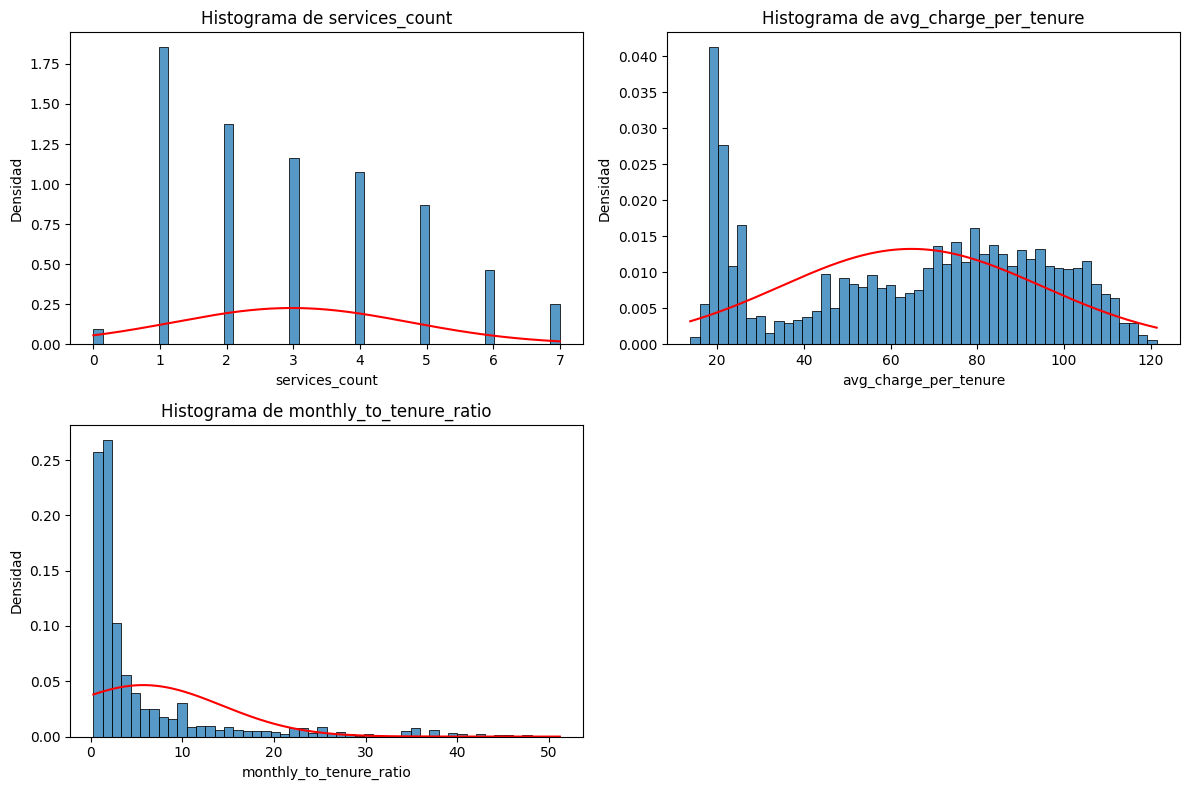

In [ ]:
visual_features = ['services_count', 'avg_charge_per_tenure', 'monthly_to_tenure_ratio']
n_cols = 2
n_rows = (len(visual_features) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten() 

for i, col in enumerate(visual_features):
    utils.histogram_plot(df_fe, col, ax=axes[i])


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 5. Limpieza final. Selección de Features

In [28]:
# Eliminamos columnas que no aportan señal directa o pueden introducir ruido
drop_cols = []

# Identificadores
for col in ["customerid"]:
    if col in df_fe.columns:
        drop_cols.append(col)

# Si existen features redundantes por construcción, se pueden excluir
# Ejemplo: si has creado is_month_to_month, quizá no quieras mantener contract si luego comparas modelos
# pero por ahora lo dejaremos.

df_model = df_fe.drop(columns=drop_cols, errors="ignore")

print("Shape final para modelado:", df_model.shape)
df_model.head()

Shape final para modelado: (7043, 32)


,customer_i_d,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,is_new_customer,is_long_term_customer,avg_charge_per_tenure,monthly_to_tenure_ratio,services_count,is_month_to_month,is_one_year_contract,is_two_year_contract,has_auto_payment,has_fiber_optic
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,1,0,29.850000,14.925000,1,1,0,0,0,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,0,1,55.573529,1.627143,3,0,1,0,0,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,1,0,54.075000,17.950000,3,1,0,0,0,0
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,0,1,40.905556,0.919565,3,0,1,0,1,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,1,0,75.825000,23.566667,1,1,0,0,0,1


# 6. Separación de target y features

In [29]:
TARGET = "churn"

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target balance:\n", y.value_counts(normalize=True))

X shape: (7043, 31)
y shape: (7043,)
Target balance:
 churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


# 7. Train/Test split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (5634, 31)
Test: (1409, 31)


Identificamos de nuevo las columnas numéricas y categóricas:

In [31]:
numeric_features = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numéricas:", numeric_features)
print("Categóricas:", categorical_features)

Numéricas: ['partner', 'dependents', 'tenure', 'phone_service', 'paperless_billing', 'monthly_charges', 'total_charges', 'family_support', 'is_new_customer', 'is_long_term_customer', 'avg_charge_per_tenure', 'monthly_to_tenure_ratio', 'services_count', 'is_month_to_month', 'is_one_year_contract', 'is_two_year_contract', 'has_auto_payment', 'has_fiber_optic']
Categóricas: ['gender', 'senior_citizen', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_t_v', 'streaming_movies', 'contract', 'payment_method']


# 8. Guardamos el dataset

In [32]:
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_model.to_csv(PROCESSED_DIR / "telco_churn_feature_engineered.csv", index=False)

print("Dataset guardado en:", PROCESSED_DIR / "telco_churn_feature_engineered.csv")

Dataset guardado en: data\processed\telco_churn_feature_engineered.csv
